In [1]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from dssp import DSSPFile
import requests

%load_ext autoreload 
%autoreload 2

In [7]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 1].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_1.faa')
# subprocess.run('muscle -align ../data/genes/cluster_1.faa -output ../data/genes/cluster_1.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_1 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_1 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_175
orfm.bz_1.1_148
orfm.bz_2.1_34
orfm.bz_3.1_50
orfm.bz_4.1_164
orfm.bz_5.1_140
orfm.bz_7.1_180
orfm.bz_8.1_206
orfm.bz_9.1_49
orfm.bz_10.1_18
orfm.bz_11.1_39

Minimum cluster_1 gene length: 138
Maximum cluster_1 gene length: 153


In [3]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)


Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_4 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [4]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'
DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_1/'

copy_structures(genes_df.index, source_dir='../data/genes/colabfold', output_dir=DSSP_INPUT_DIR)


for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
    gene_id = get_gene_id(path)
    output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
    if not os.path.exists(output_path):
        subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)

def map_dssp_to_msa(msa):
    ids, arr = list(), list()
    for gene_id, map_idxs in msa.get_map_idxs().items():
        path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
        row = np.array(list(str(DSSPFile.from_file(path))) + ['.'])
        arr.append(row[map_idxs])
        ids.append(id)
    return MSA.from_array(arr, ids)

msa = MSA.from_file('../data/genes/cluster_1.afa')
dssp_msa = map_dssp_to_msa(msa)

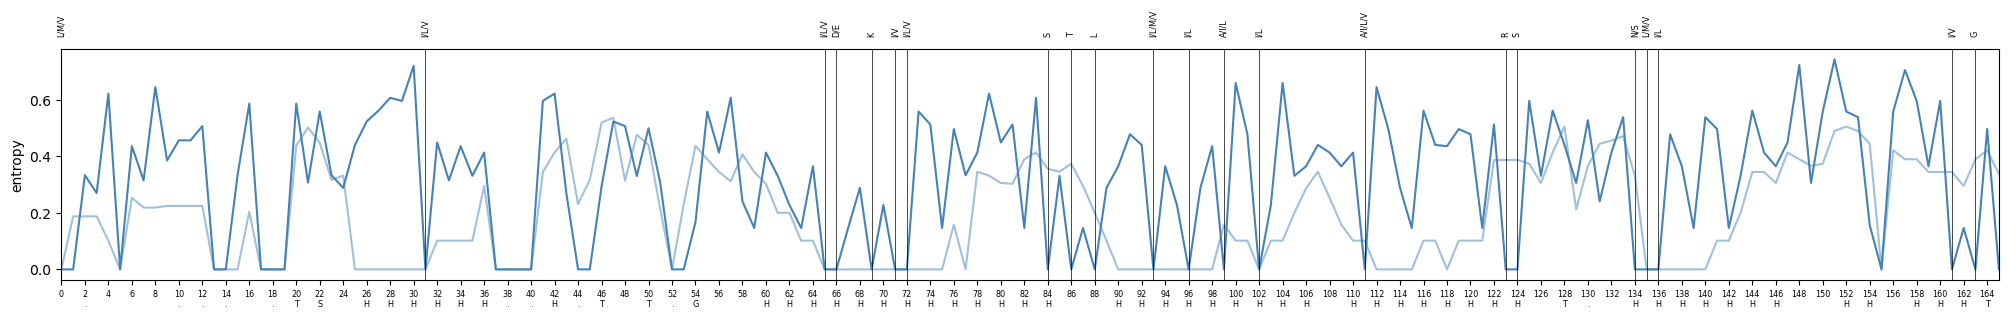

In [5]:
def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))
MAX_ENTROPY = 0.1
# x_min, x_max = 240, 270

x_min, x_max = 0,165 
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
dssp_entropy = get_entropy(dssp_msa)

ax.plot(np.arange(len(entropy)), entropy, color='steelblue')
ax.plot(np.arange(len(dssp_entropy)), dssp_entropy, color='steelblue', alpha=0.5)

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]

ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

# H, D, E, and C are potentially metal-binding. 

In [41]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

FASTAFile.from_df(foldseek_search_df.rename(columns={'tseq':'seq'}).drop_duplicates('target').set_index('target')).write('../data/genes/foldseek/cluster_1_targets.faa')
foldseek_search_df['target_has_tmh'] = foldseek_search_df.target.map(TMHMMFile.from_file('../data/genes/tmhmm/cluster_1_targets.txt').get_num_tmhs()) > 0

In [42]:
ALPHAFOLD_ACCESSION_PATTERN = r'[A-Z0-9]+$'
ALPHAFOLD_METADATA_PATH = '../data/genes/cluster_1_alphafold_metadata.tsv'

foldseek_search_targets_missing_annotation = foldseek_search_df[foldseek_search_df.theader.str.match(ALPHAFOLD_ACCESSION_PATTERN)].theader.values 
foldseek_search_targets_missing_annotation = np.unique(foldseek_search_targets_missing_annotation)

print('Number of targets missing an annotation:', len(foldseek_search_targets_missing_annotation))

if not os.path.exists(ALPHAFOLD_METADATA_PATH):
    alphafold_metadata_df = list()
    for accession in tqdm(foldseek_search_targets_missing_annotation, desc='Obtaining additional annotation information from AlphaFold.'):
        url = f'https://alphafold.ebi.ac.uk/api/prediction/{accession}'
        result = json.loads(requests.get(url).text)
        alphafold_metadata_df += result

    alphafold_metadata_df = [entry for entry in alphafold_metadata_df if (type(entry) == dict)]
    alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df).set_index('uniprotAccession')
    alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

else:
    alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

UNCHARACTERIZED_PROTEIN_PATTERN = list()
UNCHARACTERIZED_PROTEIN_PATTERN += ['putative membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain-containing protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['putative phage protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized phage protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized membrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized PPE family protein PPE1']

alphafold_metadata_df['uniprotDescription'] = alphafold_metadata_df.uniprotDescription.fillna('Uncharacterized protein')
alphafold_metadata_df.loc['A0A8S5UYN7_2', 'uniprotDescription'] = 'Endosialidase chaperone'
alphafold_metadata_df.loc['A0A481Z8K0_1', 'uniprotDescription'] = 'DNA-directed RNA polymerase'
alphafold_metadata_df.loc['A0A8S5LUT4_2', 'uniprotDescription'] = 'Tail protein'
alphafold_metadata_df.loc['UPI00200D28BD', 'uniprotDescription'] = 'Uncharacterized protein'
alphafold_metadata_df['uncharacterized'] = alphafold_metadata_df.uniprotDescription.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

print('Number of additional retrieved annotations:', (~alphafold_metadata_df.uncharacterized).sum())

annotations = alphafold_metadata_df.uniprotDescription.to_dict()
foldseek_search_df['theader'] = foldseek_search_df.theader.apply(lambda theader : annotations.get(theader, theader))
foldseek_search_df['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

Number of targets missing an annotation: 1602
Number of additional retrieved annotations: 414


In [43]:
foldseek_search_df[foldseek_search_df.theader.str.contains('oxidase')]

,query,target,evalue,gapopen,qstart,qend,qlen,tstart,tend,tlen,...,tcov,taxname,taxlineage,lddt,lddtfull,alntmscore,prob,target_database,target_has_tmh,uncharacterized
38412,orfm.bz_1.1_148,AF-P63857-F1-model_v6,0.3805,14,1,129,142,7,202,203,...,0.966,Mycobacterium tuberculosis variant bovis AF212...,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.5601,"0.531,0.806,0.600,0.545,0.346,0.482,0.583,0.67...",0.5059,0.277,alphafold_swissprot,True,False
38413,orfm.bz_1.1_148,AF-P50677-F1-model_v6,0.3734,13,1,129,142,13,198,201,...,0.925,Thermostichus vulcanus,-_cellular organisms;-_Bacteria;k_Bacillati;-_...,0.5655,"0.094,0.472,0.450,0.500,0.393,0.517,0.471,0.52...",0.4968,0.254,alphafold_swissprot,True,False
38414,orfm.bz_1.1_148,AF-P80441-F1-model_v6,0.3561,11,5,108,142,54,274,281,...,0.786,Rhizopus stolonifer,-_cellular organisms;-_Eukaryota;-_Opisthokont...,0.5527,"0.346,0.464,0.567,0.426,0.412,0.647,0.764,0.68...",0.6223,0.301,alphafold_swissprot,True,False
38415,orfm.bz_1.1_148,AF-Q5YZ19-F1-model_v6,0.3559,11,7,129,142,18,202,203,...,0.911,Nocardia farcinica IFM 10152,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.5622,"0.350,0.265,0.309,0.426,0.400,0.645,0.681,0.63...",0.4910,0.214,alphafold_swissprot,True,False
38416,orfm.bz_1.1_148,AF-P9WP67-F1-model_v6,0.3476,10,6,129,142,16,201,203,...,0.916,Mycobacterium tuberculosis H37Rv,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.5303,"0.304,0.367,0.368,0.309,0.338,0.500,0.425,0.64...",0.4777,0.196,alphafold_swissprot,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194005,orfm.bz_10.1_18,AF-A0A429S9M2-F1-model_v6,0.2963,20,41,130,148,20,178,206,...,0.772,Streptomyces sp. WAC06614,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.4172,"0.089,0.250,0.323,0.379,0.272,0.390,0.340,0.22...",0.5240,0.116,alphafold_uniprot,True,False
194015,orfm.bz_10.1_18,AF-A0A3C1JU88-F1-model_v6,0.2725,11,1,144,148,10,147,190,...,0.726,Chloroflexota bacterium,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.4141,"0.750,0.958,0.893,0.969,0.861,0.925,0.925,0.85...",0.3435,0.082,alphafold_uniprot,True,False
194017,orfm.bz_10.1_18,AF-A0A3B9Z899-F1-model_v6,0.2632,33,1,134,148,8,202,204,...,0.956,Chloroflexota bacterium,-_cellular organisms;-_Bacteria;k_Bacillati;p_...,0.3964,"0.750,0.917,0.893,0.969,0.889,0.925,0.900,0.85...",0.3500,0.076,alphafold_uniprot,True,False
194020,orfm.bz_10.1_18,AF-A0A159ZWI1-F1-model_v6,0.2581,8,44,112,148,114,210,217,...,0.447,Pseudomonas fluorescens,-_cellular organisms;-_Bacteria;k_Pseudomonada...,0.4257,"0.202,0.191,0.183,0.293,0.284,0.285,0.289,0.27...",0.5740,0.082,alphafold_uniprot,True,False


In [44]:
filters = dict()
filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.5
filters['eukaryotic'] = foldseek_search_df.taxlineage.str.contains('Eukaryota') | foldseek_search_df.theader.str.contains('human')
filters['low_query_coverage'] = foldseek_search_df.qcov < 0.5
filters['low_target_coverage'] = foldseek_search_df.tcov < 0.5
filters['synthetic'] = foldseek_search_df.theader.str.contains('Computationally designed|synthetic|de novo|De novo')
filters['target_too_long'] = foldseek_search_df.tlen > 300 
filters['has_transmembrane_helix'] = foldseek_search_df.target_has_tmh
filters['fragment'] = foldseek_search_df.theader.str.contains('fragment', case=False)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')
print()

for gene_id, df in foldseek_search_df.groupby('query'):
    print(f'Number of filtered Foldseek hits for {gene_id}:', len(df))

print('\nNumber of Foldseek hits after filtering:', len(foldseek_search_df))
print('Number of unique Foldseek hits after filtering:', foldseek_search_df.target.nunique())

apply_filters: 7 entries removed by large_e_value.
apply_filters: 3519 entries removed by low_tm_score.
apply_filters: 1673 entries removed by eukaryotic.
apply_filters: 556 entries removed by low_query_coverage.
apply_filters: 1466 entries removed by low_target_coverage.
apply_filters: 13 entries removed by synthetic.
apply_filters: 1525 entries removed by target_too_long.
apply_filters: 1746 entries removed by has_transmembrane_helix.
apply_filters: 126 entries removed by fragment.

Number of filtered Foldseek hits for orfm.bz_0.1_175: 14
Number of filtered Foldseek hits for orfm.bz_1.1_148: 21
Number of filtered Foldseek hits for orfm.bz_10.1_18: 20
Number of filtered Foldseek hits for orfm.bz_11.1_39: 11
Number of filtered Foldseek hits for orfm.bz_2.1_34: 17
Number of filtered Foldseek hits for orfm.bz_3.1_50: 45
Number of filtered Foldseek hits for orfm.bz_4.1_164: 34
Number of filtered Foldseek hits for orfm.bz_5.1_140: 28
Number of filtered Foldseek hits for orfm.bz_7.1_180: 57

In [45]:
foldseek_search_df.theader.tolist()

['AF-A0A1N6FG55-F1-model_v6 Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Late transcription elongation factor OPG087',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 '4j7k-assembly1_A The crystal structure of a secreted protein EsxB (Mutant E54Q) from Bacillus anthracis str. Sterne',
 'Repressor protein CI',
 'Membrane-anchored junction protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'AF-B3DS06-F1-model_v6 Phosphoribosyl-ATP pyrophosphatase',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 '8rdw-assembly1_To Cryo-EM structure of P. urativorans 70S ribosome in complex with hibernation factor Balon and EF-Tu(GDP) (structure 3).',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'P0 protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 'Uncharacterized protein',
 '7yh8-assembly2_C C

In [ ]:
print(foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].theader.tolist())
# 8yy1-assembly1_Z Vo domain of V/A-ATPase from Thermus thermophilus state3
# ATPase protein 9
# Q6MLJ0
# DUF4105 Domain found in putative membrane proteins in bacteria and archaea.
# Transmembrane protein 196 is human.
# T4 recombination mediator protein UvsY is not transmembrane.
# 5jsn-assembly2_D Bcl2-inhibitor complex is human.

foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].iloc[:30]

['Holin', 'AF-B1AIC5-F1-model_v6 ATP synthase subunit c', 'Uncharacterized protein', 'Uncharacterized protein', '5sv0-assembly2_J Structure of the ExbB/ExbD complex from E. coli at pH 7.0', 'Uncharacterized protein', 'Uncharacterized protein', 'Nsp2TF protein', '8yy1-assembly1_Z Vo domain of V/A-ATPase from Thermus thermophilus state3', 'Putative membrane protein', 'AF-A0A7Z9Z8W0-F1-model_v6 DUF308 domain-containing protein', 'Nsp2TF protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Membrane protein A31', 'Uncharacterized protein', 'AF-A0A4R9AJ38-F1-model_v6 DUF4233 domain-containing protein', 'Holin', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', '7wem-assembly1_A Solid-state NMR Structure of TFo c-Subunit Ring', 'AF-P71041-F1-model_v6 Uncharacterized protein YwnF', 'Uncharacterized protein', 'AF-B0TWQ4-F1-model_v6 NADH-quinone oxidoreductase subunit K', 'Uncharacterized protein', '

,theader,alntmscore,qcov,tcov
115817,Holin,0.7383,0.911,0.667
75609,AF-B1AIC5-F1-model_v6 ATP synthase subunit c,0.7302,0.782,0.569
80913,Uncharacterized protein,0.7199,0.964,0.711
81006,Uncharacterized protein,0.7169,0.796,0.541
113223,5sv0-assembly2_J Structure of the ExbB/ExbD co...,0.7086,0.708,0.949
70661,Uncharacterized protein,0.7044,0.897,0.705
115788,Uncharacterized protein,0.6971,0.932,0.711
80925,Nsp2TF protein,0.6908,0.995,0.516
107074,8yy1-assembly1_Z Vo domain of V/A-ATPase from ...,0.6889,0.777,0.890
80939,Putative membrane protein,0.6878,0.867,0.688


In [ ]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
COLABFOLD_PLDDTS = dict()

for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
    if get_gene_id(path) not in genes_df.index.values: 
        continue 

    with open(path, 'r') as f:
        scores = json.load(f)
        plddts = np.array(scores['plddt'])
        COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# fig, ax = plt.subplots(figsize=(10, 3.5))
# for gene_id, plddts in COLABFOLD_PLDDTS.items():
#     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# ax.set_xlim(xmin=0, xmax=180)
# ax.set_ylabel('pLDDT')
# ax.set_xlabel('position')
# plt.show()

pattern = '(' + '|'.join(genes_df.index) + ')' + r'_relaxed_rank_001_alphafold2_ptm_model_\d_seed_\d\d\d\.pdb'
paths = [path for path in glob.glob(os.path.join(COLABFOLD_DIR, '**', '*')) if (re.search(pattern, path) is not None)]
for path in paths:
    output_path = os.path.join('/home/prichter/Documents/banfield/betazoid/data/genes/metal3d/', f'{get_gene_id(path)}')
    cmd = f'metal3d --pdb {os.path.abspath(path)} --metalbinding --writeprobes --probefile {output_path}.pdb --maxp --writecube --cubefile {output_path}.cube --softext'
    print(cmd)

metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_0/orfm.bz_0.1_198_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_5/orfm.bz_5.1_157_relaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_1/orfm.bz_1.1_170_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prich

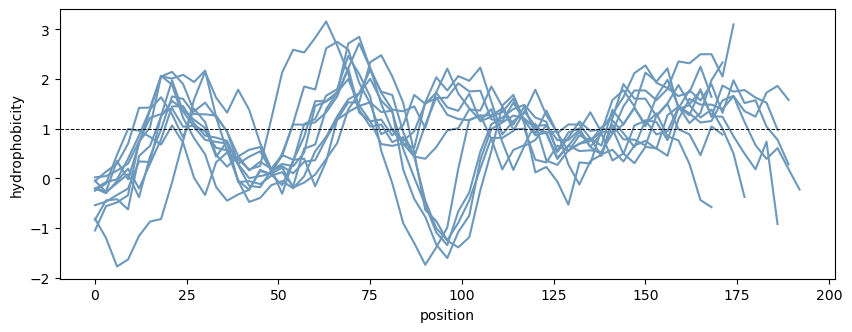

In [ ]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

window_size = 20
step_size = 3

cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

fig, ax = plt.subplots(figsize=(10, 3.5))
for row in genes_df.itertuples():
    window_starts = list(range(0, len(row.seq), step_size))[:-1]
    windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]
    hydrophobicity = [get_hydrophobicity(window) for window in windows]
    ax.plot(window_starts, hydrophobicity, label=gene_id, color=palette[gene_id])

ax.set_ylabel('hydrophobicity')
ax.set_xlabel('position')
ax.axhline(1, ls='--', color='black', lw=0.7)
plt.show()